# GNN for Airline Fare Prediction

Edge-level regression on an airport route graph. Airports are **nodes**, routes are directed **edges**, and the target is `MARKET_FARE`. A Graph Neural Network aggregates hub-neighborhood context (competition, connectivity) that a simple distance regression cannot capture.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GINEConv, GATConv

sns.set_theme(style='whitegrid')
BLUE = '#4393c3'
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

PyTorch 2.12.0.dev20260321+cu128  |  CUDA: True


## 1. Data Loading & Filtering

Load the clean dataset, apply quality filters, then draw a stratified 10% sample (by ORIGIN airport) to keep the graph connected while fitting in memory. Raw individual ticket rows are kept — no pre-aggregation, since the GNN learns to aggregate information via message passing.

In [3]:
DATA_PATH = '../../data/clean_data/T_DB1B_MARKET_CLEAN.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw:  {len(df):,} rows")

# Quality filters:
#   BULK_FARE == 0              — exclude employee/contract fares
#   MKT_GEO_TYPE == 2           — domestic contiguous US only
df = df[
    (df['BULK_FARE'] == 0) &
    (df['MKT_GEO_TYPE'] == 2)
].copy()
print(f"After filters: {len(df):,} rows ({len(df)/32_520_273:.1%} retained)")

# 10% stratified sample by ORIGIN — keeps graph connected (all hub airports represented)
# No aggregation: raw ticket rows preserve fare variance that GNN/GAT learn from
agg = df.groupby('ORIGIN').sample(frac=0.005, random_state=42).reset_index(drop=True)
print(f"Sample: {len(agg):,} rows")
agg.head()

Raw:  25,072,315 rows
After filters: 23,941,830 rows (73.6% retained)
Sample: 119,716 rows


,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
0,2025,2,10135,ABE,13577,MYR,G4,G4,G4,0.0,2.0,88.00,518.0,518.0,2,40.6521,-75.440804,33.679699,-78.928299
1,2025,2,10135,ABE,12266,IAH,UA,UA,99,0.0,1.0,470.50,1580.0,1339.0,2,40.6521,-75.440804,29.984400,-95.341400
2,2024,4,10135,ABE,13930,ORD,G7,UA,G7,0.0,1.0,212.00,655.0,655.0,2,40.6521,-75.440804,41.978600,-87.904800
3,2025,2,10135,ABE,10397,ATL,9E,DL,9E,0.0,1.0,474.00,692.0,692.0,2,40.6521,-75.440804,33.636700,-84.428101
4,2024,3,10135,ABE,11298,DFW,AA,99,99,0.0,1.0,160.96,1358.0,1307.0,2,40.6521,-75.440804,32.896801,-97.038002


In [4]:
#print out format of data
print(agg.dtypes)

YEAR                   int64
QUARTER                int64
ORIGIN_AIRPORT_ID      int64
ORIGIN                object
DEST_AIRPORT_ID        int64
DEST                  object
REPORTING_CARRIER     object
TICKET_CARRIER        object
OPERATING_CARRIER     object
BULK_FARE            float64
PASSENGERS           float64
MARKET_FARE          float64
MARKET_DISTANCE      float64
NONSTOP_MILES        float64
MKT_GEO_TYPE           int64
ORIGIN_LAT           float64
ORIGIN_LON           float64
DEST_LAT             float64
DEST_LON             float64
dtype: object


## 2. Feature Engineering

**Node features** (per airport, computed from train set only to avoid leakage): out-degree, mean departing fare. Lat/lon excluded — airport identity is already captured by ORIGIN/DEST dummies in the Ridge/MLP and by graph topology in the GNN/GAT.

**Edge features** (per raw ticket row): log distance, cyclic quarter encoding (sin/cos so Q4→Q1 wraps correctly), passengers, carrier as a learned embedding.

**Target**: `log(MARKET_FARE)` — log-transform stabilises MSE training on the right-skewed fare distribution.

In [5]:
# ── Temporal split masks ──────────────────────────────────────────────────────
train_mask = (agg['YEAR'] == 2024)                               # Q3 + Q4 2024
val_mask   = (agg['YEAR'] == 2025) & (agg['QUARTER'] == 1)      # Q1 2025
test_mask  = (agg['YEAR'] == 2025) & (agg['QUARTER'] == 2)      # Q2 2025

train_df = agg[train_mask]
print(f"Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}")

# ── Airport index ─────────────────────────────────────────────────────────────
all_airports = pd.unique(pd.concat([agg['ORIGIN'], agg['DEST']]))
airport_to_idx = {a: i for i, a in enumerate(all_airports)}
num_airports = len(all_airports)
print(f"Unique airports: {num_airports}")

# ── Node features (fit on train only) ─────────────────────────────────────────
in_degree_map = train_df.groupby('DEST')['ORIGIN'].nunique().rename('in_degree')

node_stats = (
    train_df.groupby('ORIGIN')
    .agg(
        degree       = ('DEST',           'nunique'),
        mean_fare    = ('MARKET_FARE',    'mean'),
        num_carriers = ('TICKET_CARRIER', 'nunique'),
        std_fare     = ('MARKET_FARE',    'std'),
    )
    .join(in_degree_map, how='left')
    .fillna(0)
    .reindex(all_airports, fill_value=0)
)
node_scaler = StandardScaler()
node_feat_cols = ['degree', 'in_degree', 'mean_fare', 'num_carriers', 'std_fare']
node_features = torch.tensor(
    node_scaler.fit_transform(node_stats[node_feat_cols].values),
    dtype=torch.float
)
print(f"Node feature matrix: {node_features.shape}")

# ── Carrier encoding ──────────────────────────────────────────────────────────
carriers = agg['TICKET_CARRIER'].unique()
carrier_to_idx = {c: i for i, c in enumerate(carriers)}
num_carriers = len(carriers)
print(f"Unique carriers: {num_carriers}")

# ── Macro data (quarterly) ────────────────────────────────────────────────────
jet_fuel = pd.read_csv('../../data/rawdata/JET_FUEL.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
real_dpi = pd.read_csv('../../data/rawdata/REAL_DPI.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
unrate   = pd.read_csv('../../data/rawdata/UNRATE.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
air_cpi  = pd.read_csv('../../data/rawdata/AIR_CPI.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER', 'AIR_CPI_1982-1984=100': 'AIR_CPI'})

agg = agg.merge(jet_fuel, on=['YEAR', 'QUARTER'], how='left')
agg = agg.merge(real_dpi, on=['YEAR', 'QUARTER'], how='left')
agg = agg.merge(unrate,   on=['YEAR', 'QUARTER'], how='left')
agg = agg.merge(air_cpi,  on=['YEAR', 'QUARTER'], how='left')

# ── P6 schedule data (carrier-level quarterly costs from Form 41) ─────────────
p6 = pd.concat([
    pd.read_csv('../../data/rawdata/P6_2024_Q3.csv'),
    pd.read_csv('../../data/rawdata/P6_2024_Q4.csv'),
    pd.read_csv('../../data/rawdata/P6_2025_Q1.csv'),
    pd.read_csv('../../data/rawdata/P6_2025_Q2.csv'),
], ignore_index=True)

for col in ['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']:
    p6[col] = p6[col] * 1000

p6_agg = (
    p6.groupby(['UNIQUE_CARRIER', 'YEAR', 'QUARTER'])
    [['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']]
    .sum().reset_index()
)

agg = agg.merge(
    p6_agg,
    left_on =['TICKET_CARRIER', 'YEAR', 'QUARTER'],
    right_on=['UNIQUE_CARRIER',  'YEAR', 'QUARTER'],
    how='left'
).drop(columns='UNIQUE_CARRIER')
agg[['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']] = \
    agg[['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']].fillna(0)

# ── Route HHI and carrier market share ───────────────────────────────────────
route_pax = (
    agg.groupby(['ORIGIN', 'DEST', 'YEAR', 'QUARTER', 'TICKET_CARRIER'])['PASSENGERS']
    .sum().reset_index(name='carrier_pax')
)
route_total = (
    route_pax.groupby(['ORIGIN', 'DEST', 'YEAR', 'QUARTER'])['carrier_pax']
    .sum().reset_index(name='total_pax')
)
route_pax = route_pax.merge(route_total, on=['ORIGIN', 'DEST', 'YEAR', 'QUARTER'])
route_pax['carrier_route_share'] = route_pax['carrier_pax'] / route_pax['total_pax']
route_pax['share_sq'] = route_pax['carrier_route_share'] ** 2
hhi = (
    route_pax.groupby(['ORIGIN', 'DEST', 'YEAR', 'QUARTER'])['share_sq']
    .sum().reset_index(name='route_hhi')
)
carrier_share = route_pax[['ORIGIN', 'DEST', 'YEAR', 'QUARTER', 'TICKET_CARRIER', 'carrier_route_share']]
agg = agg.merge(hhi, on=['ORIGIN', 'DEST', 'YEAR', 'QUARTER'], how='left')
agg = agg.merge(carrier_share, on=['ORIGIN', 'DEST', 'YEAR', 'QUARTER', 'TICKET_CARRIER'], how='left')

# ── Feature engineering ───────────────────────────────────────────────────────
agg['log_distance']           = np.log1p(agg['MARKET_DISTANCE'])
agg['detour_ratio']           = agg['MARKET_DISTANCE'] / agg['NONSTOP_MILES']
agg['is_short_haul']          = (agg['MARKET_DISTANCE'] < 500).astype(int)
agg['route_total_passengers'] = agg.groupby(['ORIGIN','DEST','YEAR','QUARTER'])['PASSENGERS'].transform('sum')

LCC = {'WN', 'B6', 'NK', 'F9', 'G4', 'SY', 'VX'}
agg['is_lcc'] = agg['TICKET_CARRIER'].isin(LCC).astype(int)
agg['route_has_lcc'] = agg.groupby(['ORIGIN','DEST','YEAR','QUARTER'])['is_lcc'].transform('max')



agg['carrier_idx'] = agg['TICKET_CARRIER'].map(carrier_to_idx)
agg['log_fare']    = np.log(agg['MARKET_FARE'])
agg['src_idx']     = agg['ORIGIN'].map(airport_to_idx)
agg['dst_idx']     = agg['DEST'].map(airport_to_idx)
agg['origin_num_destinations'] = agg.groupby(['ORIGIN','YEAR','QUARTER'])['DEST'].transform('nunique')
agg['dest_num_destinations']   = agg.groupby(['DEST','YEAR','QUARTER'])['ORIGIN'].transform('nunique')

# ── Edge feature matrix (scaler fit on train only) ────────────────────────────
edge_feat_cols = [
    'log_distance', 'PASSENGERS',
    'detour_ratio', 'is_short_haul', 'route_total_passengers',
    'JET_FUEL_DPG', '2017_dollars_DPI', 'UNRATE_pct', 'AIR_CPI',
    'SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS',
    'route_hhi', 'carrier_route_share', 'route_has_lcc'
]
edge_scaler = StandardScaler()
edge_scaler.fit(agg.loc[train_mask, edge_feat_cols].values)
edge_feats = edge_scaler.transform(agg[edge_feat_cols].values)

print(f"Edge feature matrix: {edge_feats.shape}")

Train: 62,097  Val: 26,392  Test: 31,227
Unique airports: 379
Node feature matrix: torch.Size([379, 5])
Unique carriers: 17
Edge feature matrix: (119716, 16)


In [6]:
# route absorbed fixed effect: mean log_fare per route computed on training set only
route_mean_fare = agg[train_mask].groupby(['ORIGIN', 'DEST'])['log_fare'].mean().rename('route_mean_logfare')
agg = agg.join(route_mean_fare, on=['ORIGIN', 'DEST'])
agg['route_mean_logfare'] = agg['route_mean_logfare'].fillna(agg.loc[train_mask, 'route_mean_logfare'].mean())

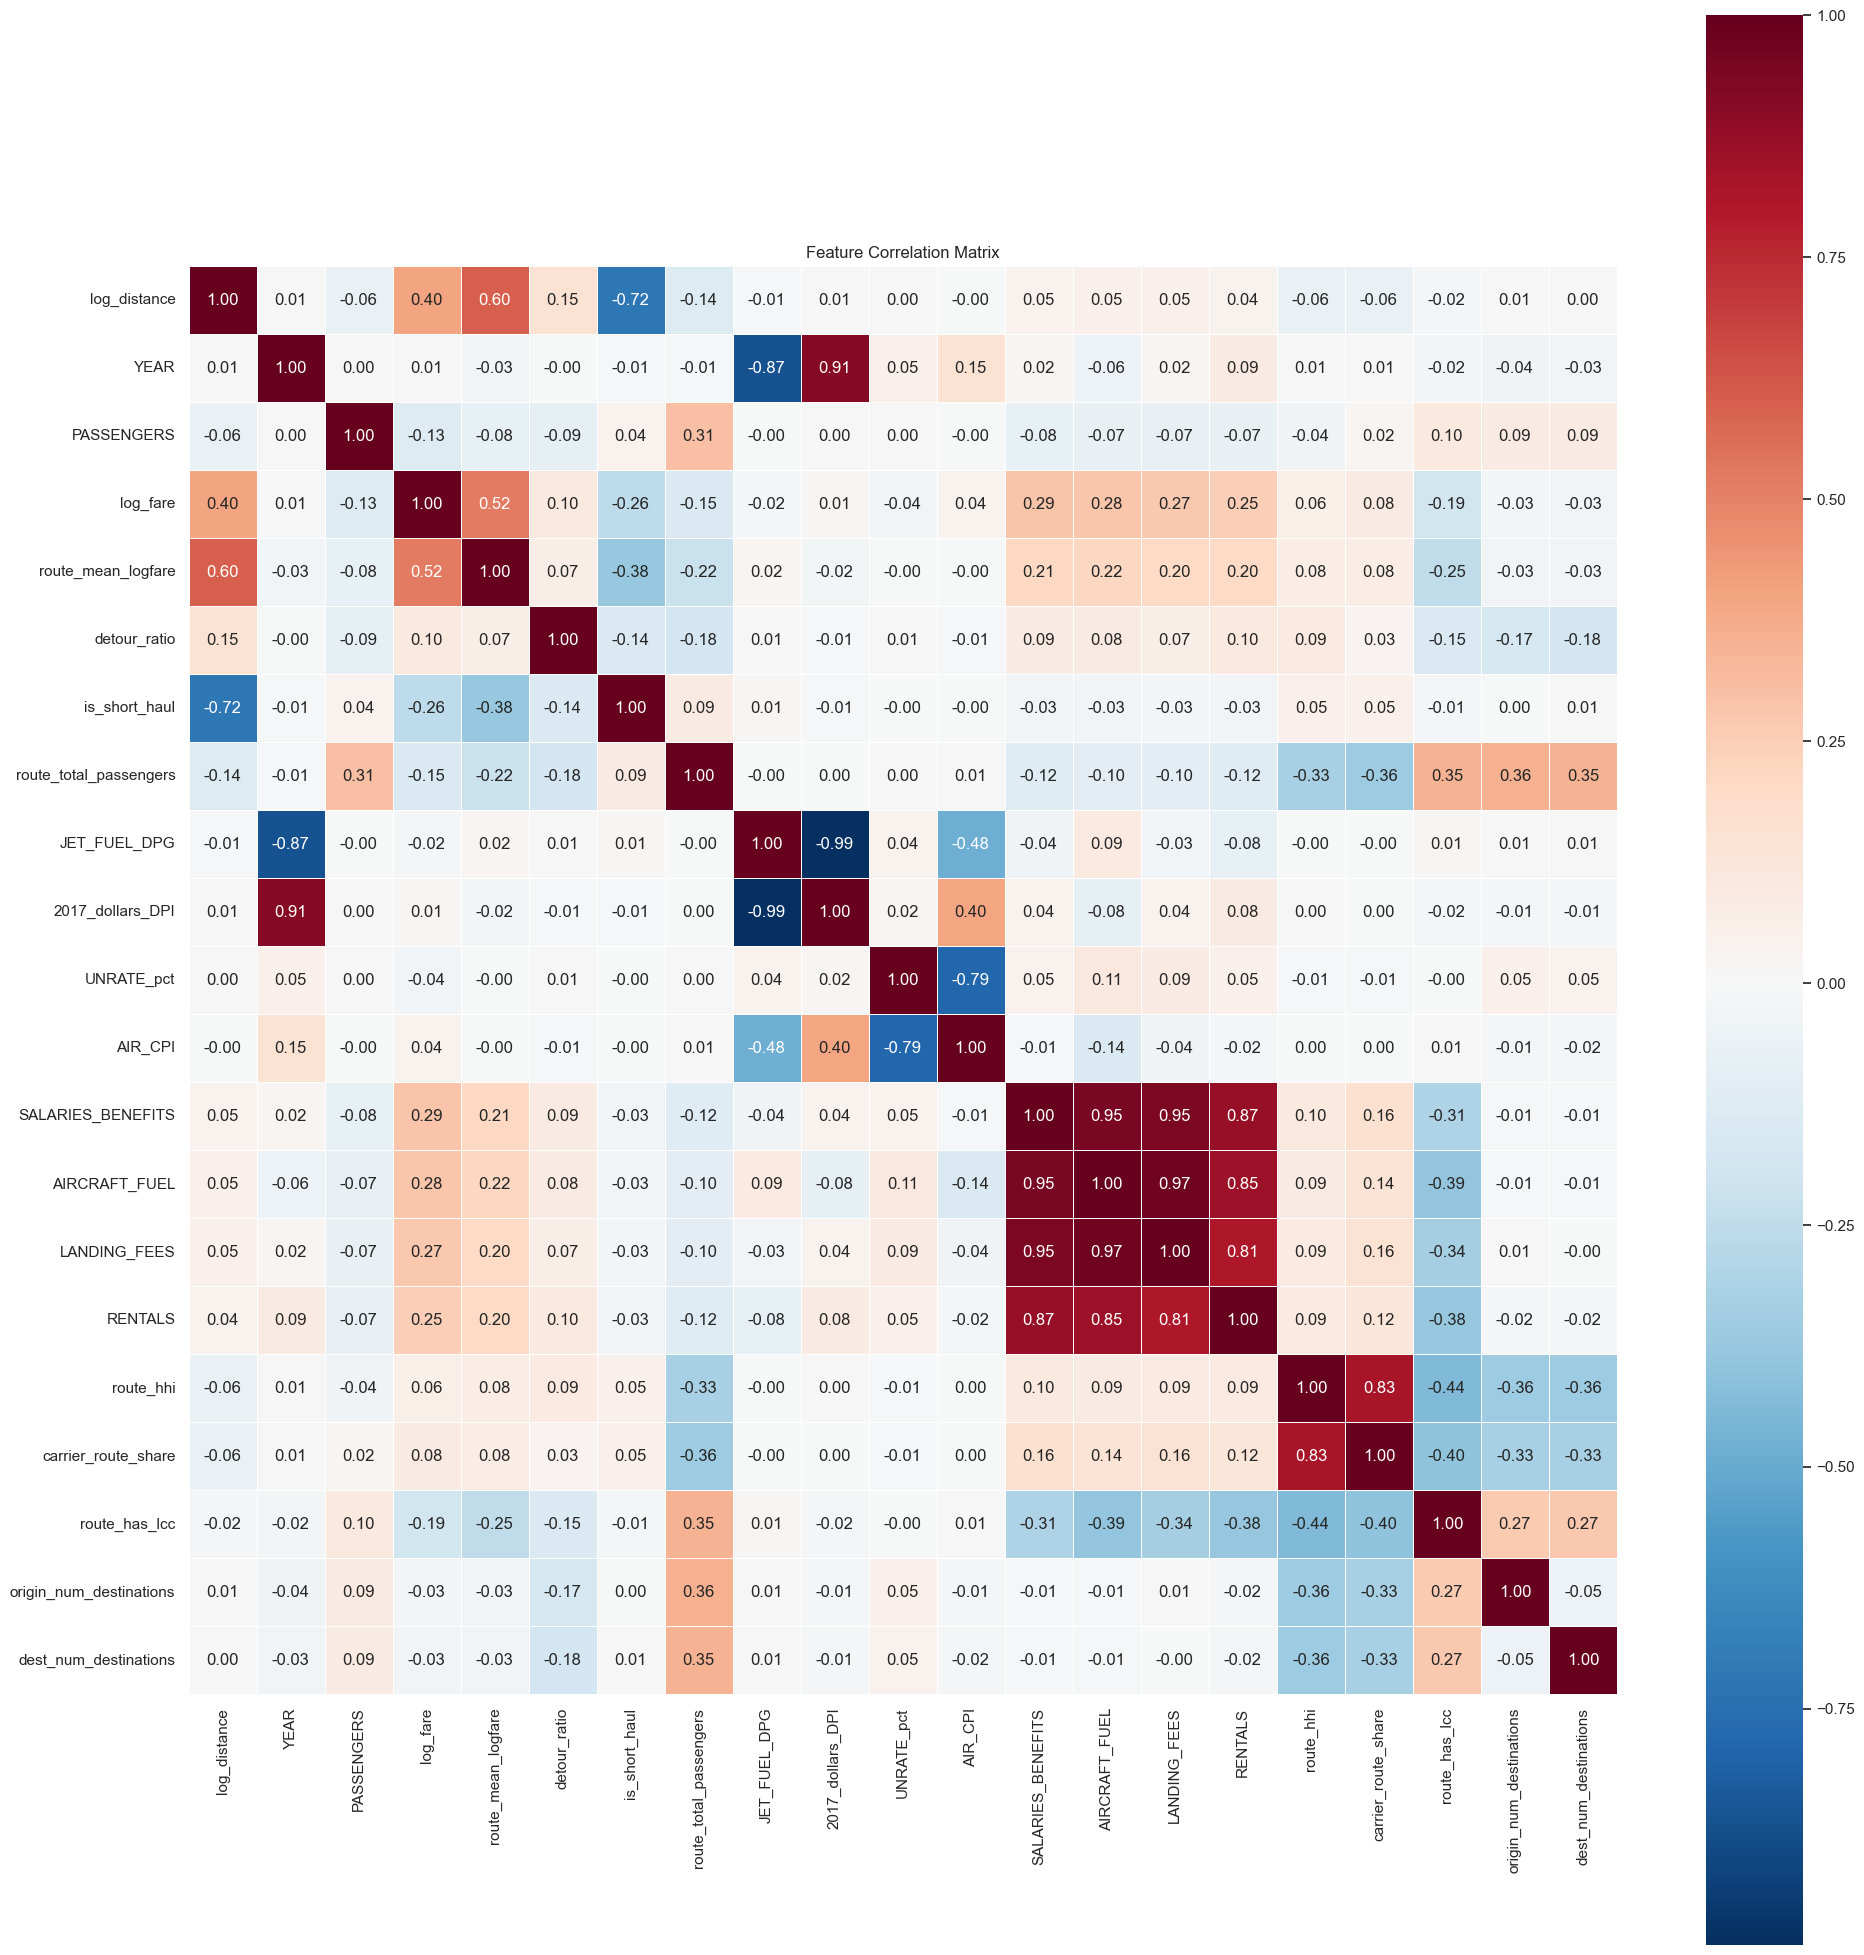

,log_distance,YEAR,PASSENGERS,log_fare,route_mean_logfare,detour_ratio,is_short_haul,route_total_passengers,JET_FUEL_DPG,2017_dollars_DPI,...,AIR_CPI,SALARIES_BENEFITS,AIRCRAFT_FUEL,LANDING_FEES,RENTALS,route_hhi,carrier_route_share,route_has_lcc,origin_num_destinations,dest_num_destinations
log_distance,1.000000,0.007099,-0.061317,0.404447,0.601737,0.150869,-0.718428,-0.136526,-0.007290,0.007560,...,-0.000044,0.047612,0.052083,0.051848,0.038219,-0.062479,-0.062553,-0.015452,0.005129,0.004769
YEAR,0.007099,1.000000,0.004279,0.008193,-0.029223,-0.004011,-0.011615,-0.011151,-0.866176,0.910338,...,0.147036,0.022017,-0.055245,0.021147,0.086895,0.007910,0.005617,-0.022278,-0.039814,-0.032506
PASSENGERS,-0.061317,0.004279,1.000000,-0.127540,-0.080280,-0.089473,0.042908,0.305219,-0.003247,0.003663,...,-0.002541,-0.076659,-0.068792,-0.071437,-0.071247,-0.038073,0.021216,0.103461,0.088041,0.087237
log_fare,0.404447,0.008193,-0.127540,1.000000,0.522404,0.103986,-0.255231,-0.149953,-0.015991,0.013472,...,0.036582,0.290839,0.283172,0.270370,0.251382,0.063202,0.082348,-0.185740,-0.026650,-0.032480
route_mean_logfare,0.601737,-0.029223,-0.080280,0.522404,1.000000,0.067690,-0.376736,-0.218576,0.021749,-0.023617,...,-0.000072,0.206177,0.220709,0.202286,0.198807,0.078249,0.080025,-0.246625,-0.032184,-0.034870
detour_ratio,0.150869,-0.004011,-0.089473,0.103986,0.067690,1.000000,-0.143599,-0.178168,0.006058,-0.005445,...,-0.010065,0.087960,0.081356,0.067589,0.100091,0.090632,0.028530,-0.151856,-0.171710,-0.179234
is_short_haul,-0.718428,-0.011615,0.042908,-0.255231,-0.376736,-0.143599,1.000000,0.085162,0.011375,-0.011683,...,-0.003126,-0.030340,-0.030698,-0.027148,-0.034221,0.052267,0.051319,-0.012976,0.000095,0.005066
route_total_passengers,-0.136526,-0.011151,0.305219,-0.149953,-0.218576,-0.178168,0.085162,1.000000,-0.002348,0.000052,...,0.010153,-0.116671,-0.103970,-0.101869,-0.115317,-0.331165,-0.363014,0.351351,0.356351,0.348070
JET_FUEL_DPG,-0.007290,-0.866176,-0.003247,-0.015991,0.021749,0.006058,0.011375,-0.002348,1.000000,-0.994375,...,-0.482483,-0.038807,0.092525,-0.034395,-0.075440,-0.002966,-0.001603,0.013599,0.010455,0.010505
2017_dollars_DPI,0.007560,0.910338,0.003663,0.013472,-0.023617,-0.005445,-0.011683,0.000052,-0.994375,1.000000,...,0.399140,0.038489,-0.083189,0.036127,0.081147,0.003722,0.002097,-0.015609,-0.013934,-0.012825


In [7]:
num_cols = [
    'log_distance', 'YEAR', 'PASSENGERS', 'log_fare', 'route_mean_logfare',
    'detour_ratio', 'is_short_haul', 'route_total_passengers',
    'JET_FUEL_DPG', '2017_dollars_DPI', 'UNRATE_pct', 'AIR_CPI',
    'SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS',
    'route_hhi', 'carrier_route_share', 'route_has_lcc', 'origin_num_destinations', 'dest_num_destinations'
]
corr = agg[num_cols].corr()

fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
agg[num_cols].corr()

## 3. Graph Construction (PyTorch Geometric)

One global graph — all quarters share the same node set (airports). Quarter and carrier are encoded as edge features, so a single `Data` object holds the full dataset with per-edge targets and split masks.

In [8]:
edge_index  = torch.tensor(agg[['src_idx', 'dst_idx']].values.T, dtype=torch.long)
edge_attr   = torch.tensor(edge_feats, dtype=torch.float)
carrier_ids = torch.tensor(agg['carrier_idx'].values, dtype=torch.long)
y           = torch.tensor(agg['log_fare'].values, dtype=torch.float)

train_idx = torch.where(torch.tensor(train_mask.values))[0]
val_idx   = torch.where(torch.tensor(val_mask.values))[0]
test_idx  = torch.where(torch.tensor(test_mask.values))[0]

data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=y)
data.carrier_ids = carrier_ids

print(f"Graph — nodes: {data.num_nodes:,}  |  edges: {data.num_edges:,}")
print(f"Node feat dim: {data.num_node_features}  |  Edge feat dim: {data.num_edge_features}")
print(f"Train edges: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}")

Graph — nodes: 379  |  edges: 119,716
Node feat dim: 5  |  Edge feat dim: 16
Train edges: 62,097  Val: 26,392  Test: 31,227


## 4. Baseline — Enhanced Ridge Regression

Ridge regression with a rich fixed-effects feature set: log-distance, cyclic quarter, year, one-hot ORIGIN (400 airports), DEST (400 airports), TICKET_CARRIER, and REPORTING_CARRIER. This is a strong benchmark — it captures most route-level fixed effects that a simple linear model can recover. The GNN must beat this to demonstrate that graph neighborhood context adds genuine value beyond what dummy variables already encode.

In [9]:
def eval_dollars(y_true_log, y_pred_log):
    """Return (RMSE $, MAE $, R² on log scale)."""
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    r2   = r2_score(y_true_log, y_pred_log)
    return rmse, mae, r2

num_cols = [
    'log_distance', 'YEAR', 'PASSENGERS',
    'detour_ratio', 'is_short_haul', 'route_total_passengers',
    'JET_FUEL_DPG', '2017_dollars_DPI', 'UNRATE_pct', 'AIR_CPI',
    'SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS',
    'route_hhi', 'carrier_route_share', 'route_has_lcc', 'origin_num_destinations', 'dest_num_destinations',
    'route_mean_logfare',
]
cat_cols = ['TICKET_CARRIER', 'REPORTING_CARRIER', 'ORIGIN', 'DEST']
X_cols   = num_cols + cat_cols

X = agg[X_cols].copy()
y_np = agg['log_fare'].values

X_train, y_train = X[train_mask], y_np[train_mask]
X_val,   y_val   = X[val_mask],   y_np[val_mask]
X_test,  y_test  = X[test_mask],  y_np[test_mask]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])
baseline = Pipeline([('pre', preprocessor), ('reg', Ridge())])
baseline.fit(X_train, y_train)

bl_val  = baseline.predict(X_val)
bl_test = baseline.predict(X_test)

rmse_v, mae_v, r2_v = eval_dollars(y_val,  bl_val)
rmse_t, mae_t, r2_t = eval_dollars(y_test, bl_test)
print(f"Ridge+  Val  — RMSE: ${rmse_v:.1f}  MAE: ${mae_v:.1f}  R²: {r2_v:.3f}")
print(f"Ridge+  Test — RMSE: ${rmse_t:.1f}  MAE: ${mae_t:.1f}  R²: {r2_t:.3f}")

Ridge+  Val  — RMSE: $118.0  MAE: $90.5  R²: 0.168
Ridge+  Test — RMSE: $114.5  MAE: $88.2  R²: 0.150


In [10]:
# checking for data shape after OHE
X_train.shape, X_val.shape, X_test.shape

((62097, 24), (26392, 24), (31227, 24))

In [11]:
for col in ['TICKET_CARRIER', 'REPORTING_CARRIER', 'ORIGIN', 'DEST']:
    print(f"{col}: {agg[col].nunique()}")

TICKET_CARRIER: 17
REPORTING_CARRIER: 25
ORIGIN: 378
DEST: 358


In [12]:
393+397+25+23+9

847

In [13]:
baseline['pre'].transform(X_train).shape[1]

756

## 5. MLP — Multilayer Perceptron

Same feature set as the enhanced Ridge (same `ColumnTransformer` preprocessing), but non-linear. A 3-hidden-layer feedforward network with BatchNorm and Dropout. Isolates whether non-linear combinations of route fixed effects help — before introducing graph structure.

Architecture: `Input (~870) → 256 → 128 → 64 → 1`

MLP input dim: 756
MLP(
  (net): Sequential(
    (0): Linear(in_features=756, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 235,905
Epoch  10  train: 1.5349  val: 0.2767
Epoch  20  train: 0.5221  val: 0.2302
Epoch  30  train: 0.4896  val: 0.2037
Epoch  40  train: 0.4756  val: 0.1989
Epoch  50  train: 0.4676  val: 0.2022
Epoch  60  tra

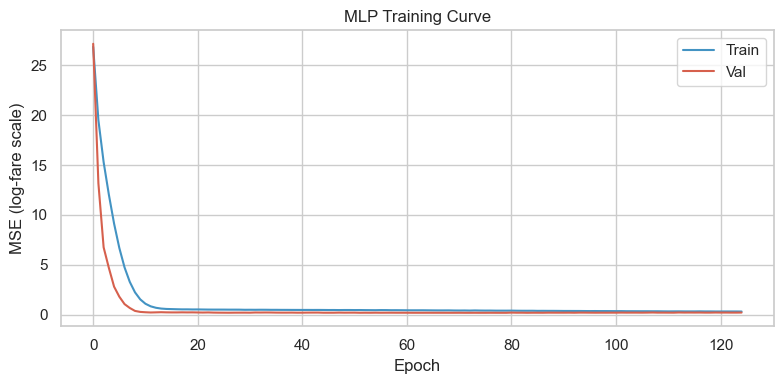

MLP     Val  — RMSE: $117.1  MAE: $89.5  R²: 0.191
MLP     Test — RMSE: $115.2  MAE: $90.3  R²: 0.129


In [14]:
# ── Preprocess with the same pipeline as Ridge ────────────────────────────────
# Reuse the fitted preprocessor so features are identical (OHE + numeric including PASSENGERS)
X_train_np = preprocessor.transform(X_train).astype(np.float32)
X_val_np   = preprocessor.transform(X_val).astype(np.float32)
X_test_np  = preprocessor.transform(X_test).astype(np.float32)
input_dim  = X_train_np.shape[1]
print(f"MLP input dim: {input_dim}")

X_tr_t  = torch.tensor(X_train_np)
X_va_t  = torch.tensor(X_val_np)
X_te_t  = torch.tensor(X_test_np)
y_tr_t  = torch.tensor(y_train.astype(np.float32))
y_va_t  = torch.tensor(y_val.astype(np.float32))

# ── Model ─────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(256, 128, 64), dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mlp_model  = MLP(input_dim).to(mlp_device)
n_params   = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(mlp_model)
print(f"\nTrainable parameters: {n_params:,}")

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 4096
optimizer  = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-5)
dataset    = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
loader     = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

X_va_d = X_va_t.to(mlp_device)
y_va_d = y_va_t.to(mlp_device)

mlp_train_losses, mlp_val_losses = [], []
best_mlp_val, best_mlp_state, mlp_patience_ctr = float('inf'), None, 0
PATIENCE = 50

for epoch in range(1, 501):
    mlp_model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(mlp_device), yb.to(mlp_device)
        optimizer.zero_grad()
        loss = F.mse_loss(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(dataset)

    mlp_model.eval()
    with torch.no_grad():
        val_loss = F.mse_loss(mlp_model(X_va_d), y_va_d).item()

    mlp_train_losses.append(epoch_loss)
    mlp_val_losses.append(val_loss)

    if val_loss < best_mlp_val:
        best_mlp_val   = val_loss
        best_mlp_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
        mlp_patience_ctr = 0
    else:
        mlp_patience_ctr += 1
        if mlp_patience_ctr >= PATIENCE:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {epoch_loss:.4f}  val: {val_loss:.4f}")

mlp_model.load_state_dict(best_mlp_state)
print(f"\nBest MLP val loss: {best_mlp_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_train_losses, label='Train', color='#4393c3')
ax.plot(mlp_val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('MLP Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

# ── Eval ──────────────────────────────────────────────────────────────────────
mlp_model.eval()
with torch.no_grad():
    mlp_val_pred  = mlp_model(X_va_t.to(mlp_device)).cpu().numpy()
    mlp_test_pred = mlp_model(X_te_t.to(mlp_device)).cpu().numpy()

mlp_rmse_v, mlp_mae_v, mlp_r2_v = eval_dollars(y_val,  mlp_val_pred)
mlp_rmse_t, mlp_mae_t, mlp_r2_t = eval_dollars(y_test, mlp_test_pred)
print(f"MLP     Val  — RMSE: ${mlp_rmse_v:.1f}  MAE: ${mlp_mae_v:.1f}  R²: {mlp_r2_v:.3f}")
print(f"MLP     Test — RMSE: ${mlp_rmse_t:.1f}  MAE: ${mlp_mae_t:.1f}  R²: {mlp_r2_t:.3f}")

## 6. GNN Model — EdgeGNN

Architecture:
1. **NodeEncoder**: linear projection of node features → hidden dimension
2. **2× SAGEConv**: message-passing layers that aggregate hub-neighborhood context
3. **EdgeDecoder**: MLP on `[src_emb ‖ dst_emb ‖ edge_feats ‖ carrier_emb]` → predicted log-fare

Carrier is a learned `nn.Embedding` (8-dim) rather than one-hot, which handles rare carriers and captures latent pricing similarities. Unlike Ridge and MLP, the GNN sees the full graph topology — each airport's embedding reflects its hub connections, competition, and pricing neighbourhood.

In [15]:
class EdgeGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, num_carriers,
                 hidden_dim=256, carrier_emb_dim=8, dropout=0.1):
        super().__init__()
        self.carrier_emb = nn.Embedding(num_carriers, carrier_emb_dim)
        self.node_enc    = nn.Linear(node_feat_dim, hidden_dim)

        mlp1 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                              nn.Linear(hidden_dim, hidden_dim))
        mlp2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                              nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(mlp1, edge_dim=edge_feat_dim)
        self.conv2 = GINEConv(mlp2, edge_dim=edge_feat_dim)

        dec_in = 2 * hidden_dim + edge_feat_dim + carrier_emb_dim
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, edge_attr, carrier_ids):
        h = F.relu(self.node_enc(x))
        h = F.relu(self.conv1(h, edge_index, edge_attr=edge_attr))
        h = F.relu(self.conv2(h, edge_index, edge_attr=edge_attr))

        src, dst = edge_index
        carrier_e = self.carrier_emb(carrier_ids)
        edge_in   = torch.cat([h[src], h[dst], edge_attr, carrier_e], dim=-1)
        return self.decoder(edge_in).squeeze(-1)


model = EdgeGNN(
    node_feat_dim  = node_features.shape[1],
    edge_feat_dim  = edge_attr.shape[1],
    num_carriers   = num_carriers,
    hidden_dim     = 256,
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

EdgeGNN(
  (carrier_emb): Embedding(17, 8)
  (node_enc): Linear(in_features=5, out_features=256, bias=True)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  ))
  (decoder): Sequential(
    (0): Linear(in_features=536, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 427,529


## 7. GNN Training

Full-graph training (all edges fit in memory). Adam with weight decay, MSE loss on log-fare, early stopping on validation loss with patience=100.

Training on: cuda
Epoch  10  train: 465396.5000  val: 193065.9844  lr: 1.00e-03
Epoch  20  train: 238374.4688  val: 57622.1641  lr: 1.00e-03
Epoch  30  train: 31243.4219  val: 4587.5732  lr: 1.00e-03
Epoch  40  train: 4159.4736  val: 141.7366  lr: 1.00e-03
Epoch  50  train: 490.7677  val: 66.2928  lr: 1.00e-03
Epoch  60  train: 54.4943  val: 30.0051  lr: 1.00e-03
Epoch  70  train: 31.1756  val: 31.4464  lr: 1.00e-03
Epoch  80  train: 30.8831  val: 29.2320  lr: 5.00e-04
Epoch  90  train: 29.8828  val: 29.9157  lr: 5.00e-04
Epoch 100  train: 29.3463  val: 29.0615  lr: 2.50e-04
Epoch 110  train: 29.0437  val: 28.6102  lr: 2.50e-04
Epoch 120  train: 28.4076  val: 28.9003  lr: 1.25e-04
Epoch 130  train: 27.7357  val: 28.7270  lr: 1.25e-04
Epoch 140  train: 27.0429  val: 28.2297  lr: 6.25e-05
Epoch 150  train: 26.5334  val: 27.5592  lr: 6.25e-05
Early stop at epoch 152

Best val loss: 17.3939


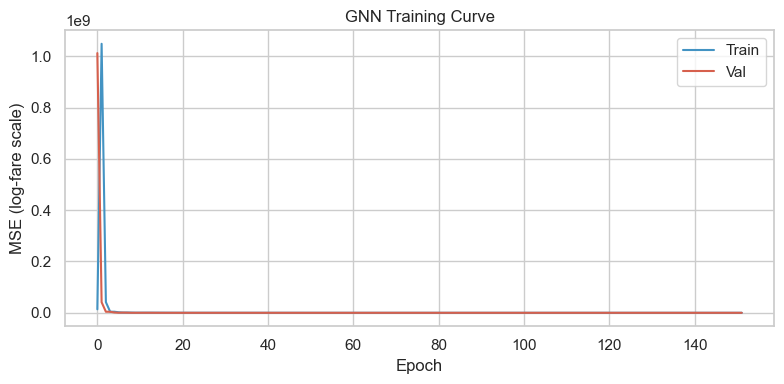

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = EdgeGNN(
    node_feat_dim = node_features.shape[1],
    edge_feat_dim = edge_attr.shape[1],
    num_carriers  = num_carriers,
    hidden_dim    = 256,
).to(device)

x_d    = data.x.to(device)
ei_d   = data.edge_index.to(device)
ea_d   = data.edge_attr.to(device)
cids_d = data.carrier_ids.to(device)
y_d    = data.y.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-5
)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, patience_ctr = 100, 0
best_state = None

for epoch in range(1, 301):
    model.train()
    optimizer.zero_grad()
    pred = model(x_d, ei_d, ea_d, cids_d)
    loss = F.mse_loss(pred[train_idx], y_d[train_idx])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_all = model(x_d, ei_d, ea_d, cids_d)
        val_loss = F.mse_loss(pred_all[val_idx], y_d[val_idx]).item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stop at epoch {epoch}")
            break

    scheduler.step(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {loss.item():.4f}  val: {val_loss:.4f}  lr: {optimizer.param_groups[0]['lr']:.2e}")

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train', color='#4393c3')
ax.plot(val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('GNN Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 8. GAT Model — EdgeGAT

Graph Attention Network variant. Identical EdgeDecoder to the GNN, but replaces SAGEConv with **GATConv** — attention weights are computed per-neighbor using edge features (`edge_dim`), so the model learns *which* connections matter most for fare prediction rather than averaging uniformly.

Architecture:
1. **NodeEncoder**: linear projection → hidden dim
2. **2× GATConv** (4 heads → 1 head): attention-weighted message passing with edge features
3. **EdgeDecoder**: same MLP on `[src_emb ‖ dst_emb ‖ edge_feats ‖ carrier_emb]` → log-fare

EdgeGAT(
  (carrier_emb): Embedding(17, 8)
  (node_enc): Linear(in_features=5, out_features=256, bias=True)
  (conv1): GATConv(256, 64, heads=4)
  (conv2): GATConv(256, 256, heads=1)
  (decoder): Sequential(
    (0): Linear(in_features=536, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 296,969
Epoch  10  train: 2.7538  val: 0.3354  lr: 1.00e-03
Epoch  20  train: 0.2923  val: 0.7940  lr: 1.00e-03
Epoch  30  train: 0.8132  val: 0.5813  lr: 1.00e-03
Epoch  40  train: 0.2357  val: 0.2053  lr: 1.00e-03
Epoch  50  train: 0.3060  val: 0.2434  lr: 1.00e-03
Epoch  60  train: 0.2300  val: 0.1830  lr: 1.00e-03
Epoch  70  train: 0.2353  val: 0.1804  lr: 1.00e-03
Epoch  80  train: 0.2258  val: 0.1780  lr: 1.00e-03
Epoch  90  train: 0.2254  val: 0.1766  lr: 1.00e-03
Epoch 100  train: 0.2234  val: 0.1

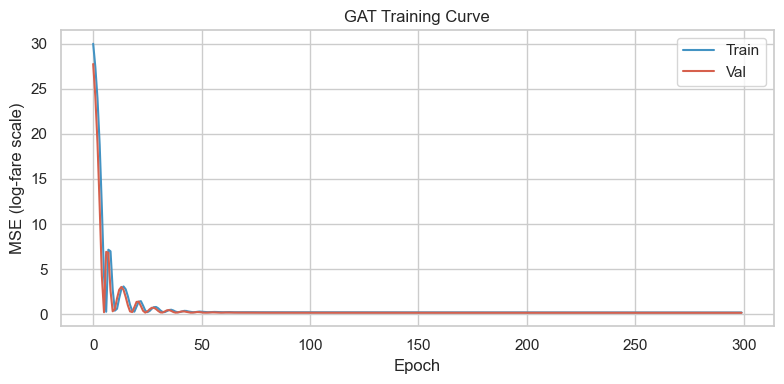

In [17]:
# ── Model ─────────────────────────────────────────────────────────────────────
class EdgeGAT(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, num_carriers,
                 hidden_dim=256, heads=4, carrier_emb_dim=8, dropout=0.1):
        super().__init__()
        self.carrier_emb = nn.Embedding(num_carriers, carrier_emb_dim)
        self.node_enc    = nn.Linear(node_feat_dim, hidden_dim)
        # GATConv with edge_dim feeds edge features into the attention coefficient
        self.conv1 = GATConv(hidden_dim, hidden_dim // heads, heads=heads,
                             edge_dim=edge_feat_dim, dropout=dropout)
        self.conv2 = GATConv(hidden_dim, hidden_dim, heads=1,
                             edge_dim=edge_feat_dim, dropout=dropout)

        dec_in = 2 * hidden_dim + edge_feat_dim + carrier_emb_dim
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),     nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, edge_attr, carrier_ids):
        h = F.relu(self.node_enc(x))
        h = F.relu(self.conv1(h, edge_index, edge_attr=edge_attr))
        h = F.relu(self.conv2(h, edge_index, edge_attr=edge_attr))
        src, dst  = edge_index
        carrier_e = self.carrier_emb(carrier_ids)
        edge_in   = torch.cat([h[src], h[dst], edge_attr, carrier_e], dim=-1)
        return self.decoder(edge_in).squeeze(-1)


gat_model = EdgeGAT(
    node_feat_dim = node_features.shape[1],
    edge_feat_dim = edge_attr.shape[1],
    num_carriers  = num_carriers,
    hidden_dim    = 256,
).to(device)
n_params = sum(p.numel() for p in gat_model.parameters() if p.requires_grad)
print(gat_model)
print(f"\nTrainable parameters: {n_params:,}")

# ── Training ──────────────────────────────────────────────────────────────────
optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_gat = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gat, mode='min', factor=0.5, patience=20, min_lr=1e-5
)

gat_train_losses, gat_val_losses = [], []
best_gat_val, best_gat_state, gat_patience_ctr = float('inf'), None, 0
PATIENCE_GAT = 100

for epoch in range(1, 301):
    gat_model.train()
    optimizer_gat.zero_grad()
    pred = gat_model(x_d, ei_d, ea_d, cids_d)
    loss = F.mse_loss(pred[train_idx], y_d[train_idx])
    loss.backward()
    optimizer_gat.step()

    gat_model.eval()
    with torch.no_grad():
        pred_all = gat_model(x_d, ei_d, ea_d, cids_d)
        val_loss = F.mse_loss(pred_all[val_idx], y_d[val_idx]).item()

    gat_train_losses.append(loss.item())
    gat_val_losses.append(val_loss)

    if val_loss < best_gat_val:
        best_gat_val   = val_loss
        best_gat_state = {k: v.clone() for k, v in gat_model.state_dict().items()}
        gat_patience_ctr = 0
    else:
        gat_patience_ctr += 1
        if gat_patience_ctr >= PATIENCE_GAT:
            print(f"Early stop at epoch {epoch}")
            break

    scheduler_gat.step(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {loss.item():.4f}  val: {val_loss:.4f}  lr: {optimizer_gat.param_groups[0]['lr']:.2e}")

gat_model.load_state_dict(best_gat_state)
print(f"\nBest GAT val loss: {best_gat_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gat_train_losses, label='Train', color='#4393c3')
ax.plot(gat_val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('GAT Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

## 9. Model Comparison

All four models evaluated on the held-out test set (2025 Q2). Metrics in original dollar scale for interpretability. Expected ordering: GAT ≥ GNN ≥ MLP ≥ Ridge+.

Model        Split   RMSE ($)   MAE ($)      R²
-------------------------------------------------------------
Ridge+       Val       118.0      90.5   0.168
Ridge+       Test      114.5      88.2   0.150
-------------------------------------------------------------
MLP          Val       117.1      89.5   0.191
MLP          Test      115.2      90.3   0.129
-------------------------------------------------------------
GNN          Val     19020.1    4730.3  -74.063
GNN          Test    19897.5    4762.6  -77.402
-------------------------------------------------------------
GAT          Val       109.9      85.0   0.277
GAT          Test      105.3      80.9   0.284
-------------------------------------------------------------


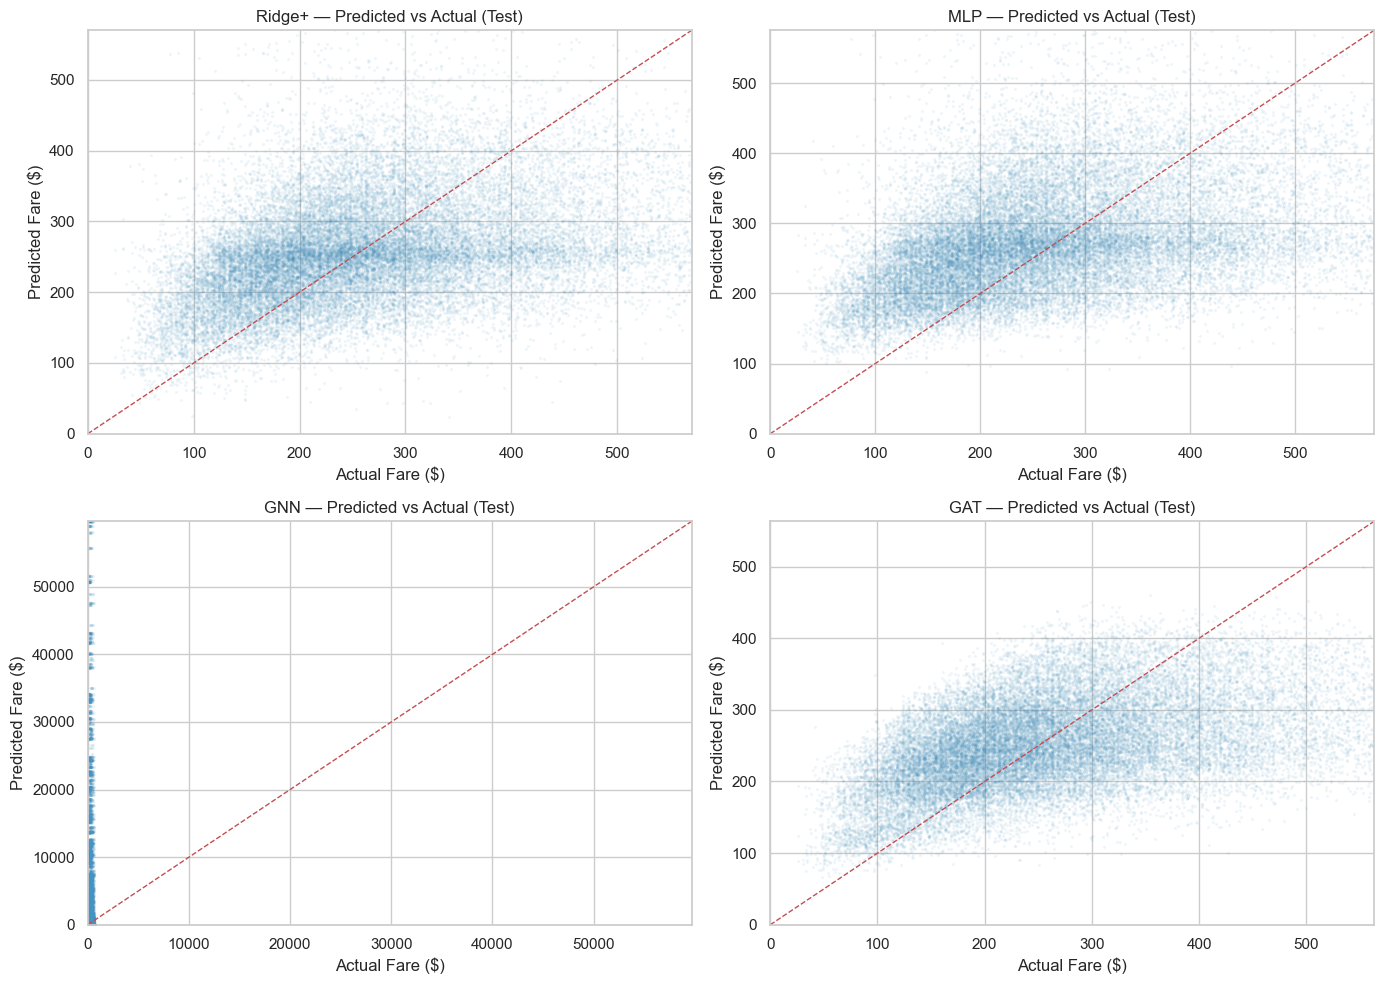

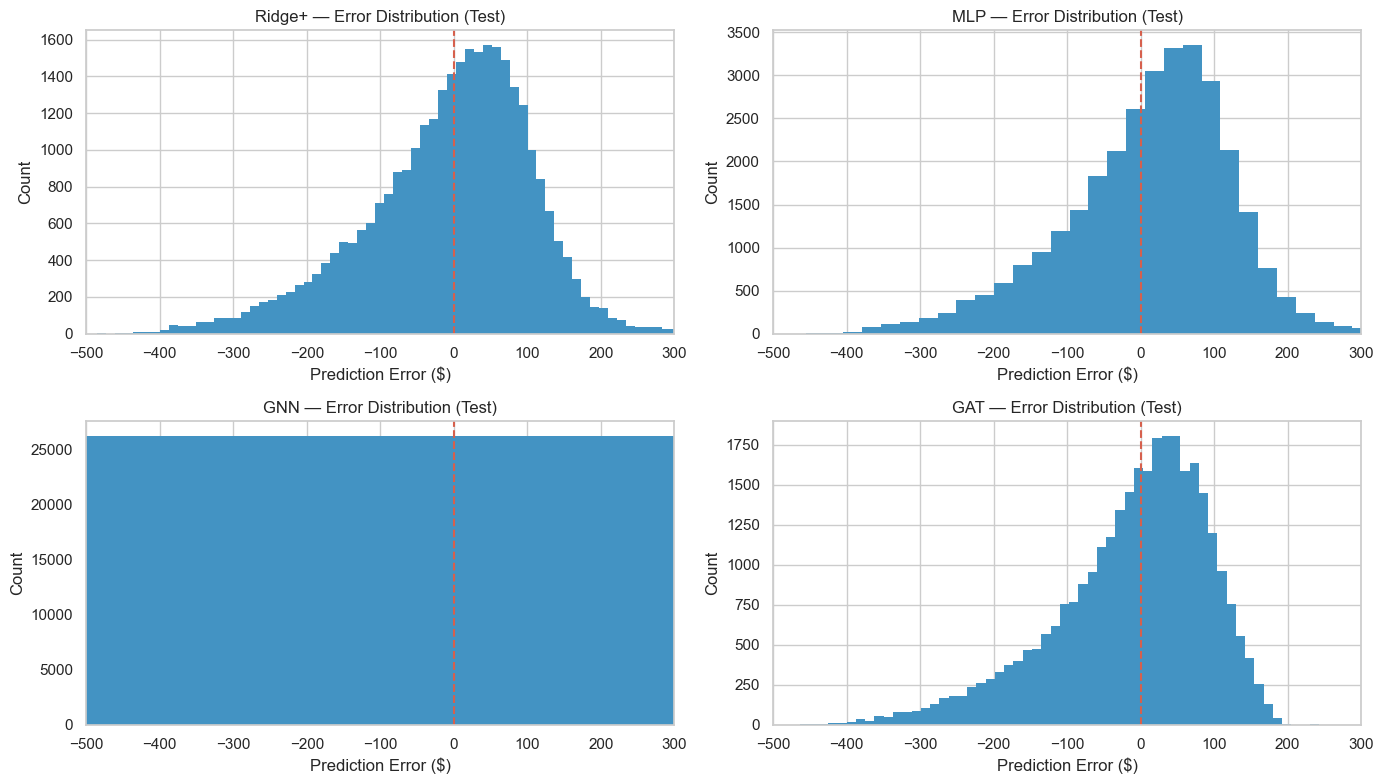


Median absolute error (test):
  Ridge+     $71.2
  MLP        $75.7
  GNN        $278.2
  GAT        $65.5


In [18]:
model.eval()
gat_model.eval()
with torch.no_grad():
    pred_log     = model(x_d, ei_d, ea_d, cids_d).cpu().numpy()
    gat_pred_log = gat_model(x_d, ei_d, ea_d, cids_d).cpu().numpy()

y_np_all = y_d.cpu().numpy()

gnn_val  = eval_dollars(y_np_all[val_idx],  pred_log[val_idx])
gnn_test = eval_dollars(y_np_all[test_idx], pred_log[test_idx])
gat_val  = eval_dollars(y_np_all[val_idx],  gat_pred_log[val_idx])
gat_test = eval_dollars(y_np_all[test_idx], gat_pred_log[test_idx])

# ── Summary Table ─────────────────────────────────────────────────────────────
print("=" * 61)
print(f"{'Model':<12} {'Split':<6} {'RMSE ($)':>9} {'MAE ($)':>9} {'R²':>7}")
print("-" * 61)
for label, rv, rt in [
    ('Ridge+', (rmse_v,     mae_v,     r2_v),     (rmse_t,     mae_t,     r2_t)),
    ('MLP',    (mlp_rmse_v, mlp_mae_v, mlp_r2_v), (mlp_rmse_t, mlp_mae_t, mlp_r2_t)),
    ('GNN',    gnn_val,                            gnn_test),
    ('GAT',    gat_val,                            gat_test),
]:
    rmse_rv, mae_rv, r2_rv = rv
    rmse_rt, mae_rt, r2_rt = rt
    print(f"{label:<12} {'Val':<6} {rmse_rv:>8.1f}  {mae_rv:>8.1f}  {r2_rv:>6.3f}")
    print(f"{label:<12} {'Test':<6} {rmse_rt:>8.1f}  {mae_rt:>8.1f}  {r2_rt:>6.3f}")
    print("-" * 61)

# ── Predicted vs Actual (Test) — all 4 models ─────────────────────────────────
y_true_test = np.exp(y_np_all[test_idx])
preds_test = {
    'Ridge+': bl_test,
    'MLP':    mlp_test_pred,
    'GNN':    pred_log[test_idx],
    'GAT':    gat_pred_log[test_idx],
}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (label, y_pred_log) in zip(axes.flat, preds_test.items()):
    y_pred = np.exp(y_pred_log)
    ax.scatter(y_true_test, y_pred, alpha=0.05, s=2, color=BLUE)
    lim = np.percentile(np.concatenate([y_true_test, y_pred]), 99)
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Actual Fare ($)'); ax.set_ylabel('Predicted Fare ($)')
    ax.set_title(f'{label} — Predicted vs Actual (Test)')
plt.tight_layout(); plt.show()

# ── Error Distribution (Test) ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (label, y_pred_log) in zip(axes.flat, preds_test.items()):
    errors = np.exp(y_pred_log) - y_true_test
    ax.hist(errors, bins=80, color=BLUE, edgecolor='none')
    ax.axvline(0, color='#d6604d', linestyle='--', linewidth=1.5)
    ax.set_xlim(-500, 300)
    ax.set_xlabel('Prediction Error ($)'); ax.set_ylabel('Count')
    ax.set_title(f'{label} — Error Distribution (Test)')
plt.tight_layout(); plt.show()

print("\nMedian absolute error (test):")
for label, y_pred_log in preds_test.items():
    med = np.median(np.abs(np.exp(y_pred_log) - y_true_test))
    print(f"  {label:<10} ${med:.1f}")